# Employee Case Analysis and Recommendation Model

This notebook analyzes `rcm.rcm.vw_bsml_daily_visit` at two levels:

1. **Historical analysis** by employee and case mix (`TestName` x `PayorName`)
2. **Daily analysis** using `production_date`, with extra focus on each employee's best days

It also builds a simple **recommendation model** to suggest which case combinations each employee performs best on.

## Output tables created in Python

- `df_raw`: raw data from the Snowflake view
- `daily_combo`: employee x production_date x testname x payorname
- `historical_combo`: historical summary by employee x testname x payorname
- `employee_best_day_overall`: each employee's best overall day
- `employee_best_day_combo`: each employee's best day for each test-payor combo
- `employee_recommendations`: ranked recommendation table for each employee

## Assumptions

- `vw_bsml_daily_visit` is already at the grain of:
  - `production_date`
  - `matched_employee_name`
  - `visitfid`
  - `TestName`
  - `PayorName`
- `total_cases_worked` in the view represents **touches/reworks** for that visit on that day.
- A **unique case** here is proxied by `visitfid`.


In [1]:
# Install packages if needed
# Uncomment if your environment does not already have these.
# !pip install snowflake-connector-python pandas numpy matplotlib openpyxl sqlalchemy snowflake-sqlalchemy


In [2]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from snowflake import connector

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)


## 1. Snowflake connection

Fill in your credentials below, or replace this block with your team's preferred auth method.


In [3]:
CONFIG_FILE_PATH = os.path.abspath(r"C:\Users\25889\Desktop\BI\ANALYTICS\snowflake_config.json")

In [4]:
def load_snowflake_config(config_path):
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file not found: {config_path}")

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    required_keys = [
        "account",
        "user",
        "authenticator",
        "role",
        "warehouse",
        "database",
        "schema"
    ]

    missing_keys = [key for key in required_keys if not config.get(key)]
    if missing_keys:
        raise ValueError(f"Missing required config keys: {missing_keys}")

    return config

In [5]:
# SNOWFLAKE_CONFIG = {
#     'user': os.getenv('SNOWFLAKE_USER', 'YOUR_USER'),
#     'password': os.getenv('SNOWFLAKE_PASSWORD', 'YOUR_PASSWORD'),
#     'account': os.getenv('SNOWFLAKE_ACCOUNT', 'YOUR_ACCOUNT'),
#     'warehouse': os.getenv('SNOWFLAKE_WAREHOUSE', 'YOUR_WAREHOUSE'),
#     'database': os.getenv('SNOWFLAKE_DATABASE', 'RCM'),
#     'schema': os.getenv('SNOWFLAKE_SCHEMA', 'RCM'),
#     'role': os.getenv('SNOWFLAKE_ROLE', 'YOUR_ROLE')
# }

config = load_snowflake_config(CONFIG_FILE_PATH)

def get_snowflake_connection(config: dict):
    return connector.connect(
            account=config["account"],
            user=config["user"],
            authenticator=config["authenticator"],
            role=config["role"],
            warehouse=config["warehouse"],
            database=config["database"],
            schema=config["schema"]
        )


## 2. Load data from the view

You can optionally add a date filter in the SQL if you want to limit volume.


In [6]:
SQL = '''
SELECT
    production_date,
    matched_employee_name,
    matched_email,
    matched_shore,
    visitfid,
    TestName,
    PayorName,
    total_cases_worked
FROM rcm.rcm.vw_bsml_daily_visit
WHERE matched_employee_name IS NOT NULL
  AND production_date IS NOT NULL
  AND visitfid IS NOT NULL
'''

with get_snowflake_connection(config) as conn:
    df_raw = pd.read_sql(SQL, conn)

print(df_raw.shape)
df_raw.head()


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://natera.okta.com/app/snowflake/exk13gguvezM93nzC297/sso/saml?SAMLRequest=jZJbc9owEIX%2Fikd9xpJNLkWDyTgQGpqQUjCdNG%2BKvTgqtuRqZQz8%2BgoTOulDMn3T5Rzttzrbv9qWhbcBg1KriAQ%2BIx6oVGdS5RFZJuPOZ%2BKhFSoThVYQkR0guRr0UZRFxePavqg5%2FK4BreceUsjbi4jURnEtUCJXogTkNuWLeHrPQ5%2FxymirU12QN5aPHQIRjHWEJ0uG0uG9WFtxSpum8Zuur01OQ8YYZT3qVAfJp5N%2B63p6Rx9QdnbQO4WTz17ZrqU6fsFHWM9HEfLbJJl1Zt8WCfHiE%2BpQK6xLMAswG5nCcn5%2FBEBH8BAnN%2FPYR6WbVSHWkOqyqq17yncruoKMFjqXrtvJKCLVWmZlWIchrtJd%2BphPr%2BfPT6Nh%2BR1Gq19fvorHO72fp7fj7GZpl%2BpnSrwfpzjDQ5wTxBom6hCidUcsvOiw8w67TIILft7j7MwPu70n4o1ciFIJ2zpPpG4PRvh6bUXLJqqK%2FsWmsF0H3TyvN7Cf9rpqPwx7lxRR00Ok5DglvK1vBv%2FVe5%2B%2BtbxO2YP7%2BMlopguZ7ryxNqWw7%2BcS%2BEF7IrPOqpVyKIUs4iwzgOjyKQrdDA24viJiTQ2EDo5V%2Fx3nwR8%3D&RelayState=ver%3A3-hint%3A44740940372450-ETMsDgAAAZ4DYOyvABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEIS5aPgxEaC8oMiKxArH6GIAAACQgieCWAdRzNoJssudaP0s9IineaGGUVkaK4

,PRODUCTION_DATE,MATCHED_EMPLOYEE_NAME,MATCHED_EMAIL,MATCHED_SHORE,VISITFID,TESTNAME,PAYORNAME,TOTAL_CASES_WORKED
0,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19500208,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1
1,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19520544,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1
2,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19520733,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1
3,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19616392,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1
4,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19621145,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1


## 3. Data cleaning and standardization

In [7]:
df = df_raw.copy()

# Standardize columns
rename_map = {
    'PRODUCTION_DATE': 'production_date',
    'MATCHED_EMPLOYEE_NAME': 'matched_employee_name',
    'MATCHED_EMAIL': 'matched_email',
    'MATCHED_SHORE': 'matched_shore',
    'VISITFID': 'visitfid',
    'TESTNAME': 'testname',
    'PAYORNAME': 'payorname',
    'TOTAL_CASES_WORKED': 'total_cases_worked'
}
df = df.rename(columns={c: rename_map.get(c, c.lower()) for c in df.columns})

df['production_date'] = pd.to_datetime(df['production_date']).dt.date

for col in ['matched_employee_name', 'matched_email', 'matched_shore', 'testname', 'payorname']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'': np.nan, 'None': np.nan, 'nan': np.nan})

# Fill missing categoricals with business-friendly labels
df['testname'] = df['testname'].fillna('UNKNOWN_TEST')
df['payorname'] = df['payorname'].fillna('UNKNOWN_PAYOR')
df['matched_shore'] = df['matched_shore'].fillna('UNKNOWN_SHORE')

df['total_cases_worked'] = pd.to_numeric(df['total_cases_worked'], errors='coerce').fillna(0)

# Each row in vw_bsml_daily_visit is one employee-day-visit combination.
# So this acts as a unique case row at the day level.
df['unique_case_count'] = 1

print(df.shape)
df.head()


(3278654, 9)


,production_date,matched_employee_name,matched_email,matched_shore,visitfid,testname,payorname,total_cases_worked,unique_case_count
0,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19500208,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1,1
1,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19520544,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1,1
2,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19520733,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1,1
3,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19616392,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1,1
4,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,19621145,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,1,1


## 4. Quick data quality checks

In [8]:
summary = {
    'rows': len(df),
    'employees': df['matched_employee_name'].nunique(dropna=True),
    'tests': df['testname'].nunique(dropna=True),
    'payors': df['payorname'].nunique(dropna=True),
    'visits': df['visitfid'].nunique(dropna=True),
    'min_date': df['production_date'].min(),
    'max_date': df['production_date'].max(),
}
summary


{'rows': 3278654,
 'employees': 1220,
 'tests': 19,
 'payors': 2757,
 'visits': 1474168,
 'min_date': datetime.date(2025, 1, 1),
 'max_date': datetime.date(2026, 5, 6)}

In [9]:
# Top missing / unknown rates
quality = pd.DataFrame({
    'column': ['testname', 'payorname', 'matched_shore'],
    'unknown_or_null_rows': [
        int((df['testname'] == 'UNKNOWN_TEST').sum()),
        int((df['payorname'] == 'UNKNOWN_PAYOR').sum()),
        int((df['matched_shore'] == 'UNKNOWN_SHORE').sum()),
    ],
    'pct_of_rows': [
        (df['testname'] == 'UNKNOWN_TEST').mean(),
        (df['payorname'] == 'UNKNOWN_PAYOR').mean(),
        (df['matched_shore'] == 'UNKNOWN_SHORE').mean(),
    ]
})
quality


,column,unknown_or_null_rows,pct_of_rows
0,testname,0,0.000000
1,payorname,727,0.000222
2,matched_shore,25245,0.007700


## 5. Build the daily combo table

This is the most important dataset for your director's ask.

Grain:
- employee
- production_date
- testname
- payorname

Metrics:
- `daily_touches`: sum of touches/reworks
- `daily_unique_cases`: number of unique visit-level rows for that day and combo


In [10]:
daily_combo = (
    df.groupby([
        'production_date',
        'matched_employee_name',
        'matched_email',
        'matched_shore',
        'testname',
        'payorname'
    ], dropna=False)
      .agg(
          daily_touches=('total_cases_worked', 'sum'),
          daily_unique_cases=('visitfid', 'nunique'),
          daily_case_rows=('unique_case_count', 'sum')
      )
      .reset_index()
)

# touches per unique case = how many times the same cases were worked/reworked on average
# lower may indicate cleaner processing; higher may indicate more rework/touches.
daily_combo['touches_per_case'] = (
    daily_combo['daily_touches'] / daily_combo['daily_unique_cases'].replace(0, np.nan)
)

print(daily_combo.shape)
daily_combo.head()


(1102806, 10)


,production_date,matched_employee_name,matched_email,matched_shore,testname,payorname,daily_touches,daily_unique_cases,daily_case_rows,touches_per_case
0,2025-01-01,Aadarsh Kallu Tiwari,aatiwari@natera.com,CGS,SIGNATERA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,31,31,31,1.0
1,2025-01-01,Aakash Ravi Pardeshi,aapardeshi@natera.com,CGS,PROSPERA,CIGNA HEALTHCARE,1,1,1,1.0
2,2025-01-01,Aakash Ravi Pardeshi,aapardeshi@natera.com,CGS,SIGNATERA,CIGNA HEALTHCARE,9,9,9,1.0
3,2025-01-01,Abhay Shivshankar Gupta,abgupta@natera.com,CGS,HORIZON,AMBETTER FROM SUNSHINE HEALTH,25,25,25,1.0
4,2025-01-01,Abhay Shivshankar Gupta,abgupta@natera.com,CGS,HORIZON,AMBETTER FROM SUPERIOR HEALTH,1,1,1,1.0


## 6. Historical analysis by employee x test x payor

This summarizes each employee's history for each test-payor combination.

Key columns:
- `active_days`: on how many days this combo appeared for the employee
- `historical_total_touches`
- `historical_total_unique_cases`
- `avg_daily_unique_cases`
- `max_daily_unique_cases`
- `consistency_cv_cases`: coefficient of variation; lower is more stable


In [11]:
historical_combo = (
    daily_combo.groupby([
        'matched_employee_name',
        'matched_email',
        'matched_shore',
        'testname',
        'payorname'
    ], dropna=False)
    .agg(
        active_days=('production_date', 'nunique'),
        historical_total_touches=('daily_touches', 'sum'),
        historical_total_unique_cases=('daily_unique_cases', 'sum'),
        avg_daily_touches=('daily_touches', 'mean'),
        median_daily_touches=('daily_touches', 'median'),
        max_daily_touches=('daily_touches', 'max'),
        std_daily_touches=('daily_touches', 'std'),
        avg_daily_unique_cases=('daily_unique_cases', 'mean'),
        median_daily_unique_cases=('daily_unique_cases', 'median'),
        max_daily_unique_cases=('daily_unique_cases', 'max'),
        std_daily_unique_cases=('daily_unique_cases', 'std'),
        avg_touches_per_case=('touches_per_case', 'mean')
    )
    .reset_index()
)

historical_combo['std_daily_touches'] = historical_combo['std_daily_touches'].fillna(0)
historical_combo['std_daily_unique_cases'] = historical_combo['std_daily_unique_cases'].fillna(0)

historical_combo['consistency_cv_cases'] = (
    historical_combo['std_daily_unique_cases'] /
    historical_combo['avg_daily_unique_cases'].replace(0, np.nan)
)

historical_combo['consistency_cv_touches'] = (
    historical_combo['std_daily_touches'] /
    historical_combo['avg_daily_touches'].replace(0, np.nan)
)

historical_combo = historical_combo.sort_values(
    ['matched_employee_name', 'historical_total_unique_cases'],
    ascending=[True, False]
)

print(historical_combo.shape)
historical_combo.head(20)


(314983, 19)


,matched_employee_name,matched_email,matched_shore,testname,payorname,active_days,historical_total_touches,historical_total_unique_cases,avg_daily_touches,median_daily_touches,max_daily_touches,std_daily_touches,avg_daily_unique_cases,median_daily_unique_cases,max_daily_unique_cases,std_daily_unique_cases,avg_touches_per_case,consistency_cv_cases,consistency_cv_touches
10,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,AETNA - COMM,68,691,691,10.161765,6.0,48,11.235087,10.161765,6.0,48,11.235087,1.000000,1.105624,1.105624
392,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,UNITED HEALTH CARE UMR,34,167,167,4.911765,3.0,26,5.212849,4.911765,3.0,26,5.212849,1.000000,1.061299,1.061299
170,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,FLORIDA BLUE - COMM,22,161,161,7.318182,4.0,30,8.242667,7.318182,4.0,30,8.242667,1.000000,1.126327,1.126327
124,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,CIGNA HEALTHCARE,50,159,159,3.180000,2.0,12,2.782526,3.180000,2.0,12,2.782526,1.000000,0.875008,0.875008
250,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,MCS - COMM,23,165,159,7.173913,7.0,18,5.556750,6.913043,7.0,18,5.204133,1.023715,0.752799,0.774577
82,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,BLUE CROSS BLUE SHIELD OF ALABAMA - COMM,24,120,120,5.000000,2.5,34,7.757185,5.000000,2.5,34,7.757185,1.000000,1.551437,1.551437
265,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,MERITAIN HEALTH,33,116,116,3.515152,2.0,16,3.658220,3.515152,2.0,16,3.658220,1.000000,1.040701,1.040701
312,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,PREMERA BLUE CROSS OF WASHINGTON - COMM,26,117,116,4.500000,1.5,26,6.586350,4.461538,1.0,26,6.604427,1.038462,1.480303,1.463633
51,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ANTHEM BLUE CROSS BLUE SHIELD COLORADO - COMM,23,85,85,3.695652,3.0,13,3.211270,3.695652,3.0,13,3.211270,1.000000,0.868932,0.868932
213,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,HORIZON BLUE CROSS BLUE SHIELD OF NEW JERSEY -...,33,83,83,2.515152,2.0,8,1.954501,2.515152,2.0,8,1.954501,1.000000,0.777091,0.777091


## 7. Best historical combo for each employee

This answers:
- historically, which test-payor combo has the strongest volume for each employee?
- which combo gives them the highest average daily unique cases?


In [12]:
# Best by total historical unique cases
employee_best_historical_volume = (
    historical_combo.sort_values(
        ['matched_employee_name', 'historical_total_unique_cases', 'avg_daily_unique_cases'],
        ascending=[True, False, False]
    )
    .groupby('matched_employee_name', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

# Best by average daily efficiency
employee_best_historical_efficiency = (
    historical_combo.sort_values(
        ['matched_employee_name', 'avg_daily_unique_cases', 'max_daily_unique_cases', 'active_days'],
        ascending=[True, False, False, False]
    )
    .groupby('matched_employee_name', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

employee_best_historical_volume.head(20), employee_best_historical_efficiency.head(20)


(              matched_employee_name          matched_email matched_shore   testname                                  payorname  active_days  historical_total_touches  historical_total_unique_cases  \
 0          ABHISHEK SRINIVAS CHIPPA     ACHIPPA@NATERA.COM           CGS   PANORAMA                               AETNA - COMM           68                       691                            691   
 1                     ADARSH PANDEY    ADPANDEY@NATERA.COM           CGS   PANORAMA  AMERIHEALTH CARITAS NORTH CAROLINA - MAMC           49                       375                            375   
 2           ADITI OMPRAKASH SAKHARE    asakhare@natera.com           CGS   PANORAMA                               AETNA - COMM          126                       649                            648   
 3            ADITI VISHWAS SHEVKARI   ASHEVKARI@NATERA.COM           CGS   PANORAMA                  TRICARE WEST AFTER 1/1/25           20                       186                            18

## 8. Daily best-day analysis

This is the more important level.

We identify:
- each employee's best day overall
- each employee's best day for each test-payor combo


In [13]:
# Overall best day per employee
employee_best_day_overall = (
    daily_combo.sort_values(
        ['matched_employee_name', 'daily_unique_cases', 'daily_touches'],
        ascending=[True, False, False]
    )
    .groupby('matched_employee_name', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

employee_best_day_overall.head(10)


,production_date,matched_employee_name,matched_email,matched_shore,testname,payorname,daily_touches,daily_unique_cases,daily_case_rows,touches_per_case
0,2026-01-05,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,AETNA - COMM,48,48,48,1.0
1,2026-02-09,ADARSH PANDEY,ADPANDEY@NATERA.COM,CGS,PANORAMA,AMERIHEALTH CARITAS NORTH CAROLINA - MAMC,34,34,34,1.0
2,2026-01-02,ADITI OMPRAKASH SAKHARE,asakhare@natera.com,CGS,PANORAMA,AETNA - COMM,48,48,48,1.0
3,2025-07-22,ADITI VISHWAS SHEVKARI,ASHEVKARI@NATERA.COM,CGS,PANORAMA,TRICARE WEST AFTER 1/1/25,52,52,52,1.0
4,2025-09-05,ANIKET NANDKISHOR HAGWANE,AHAGWANE@NATERA.COM,CGS,PANORAMA,COMMUNITY HEALTH CHOICE MEDICAID,55,55,55,1.0
5,2026-01-06,ANJALI SHRIKRISHNA WADHOKAR,awadhokar@natera.com,CGS,PANORAMA,HORIZON HEALTH NJ,50,50,50,1.0
6,2025-11-21,ANKITA KARALE,akarale@natera.com,CGS,PANORAMA,AMERIGROUP/WELLPOINT MD - MAMC,40,40,40,1.0
7,2026-01-30,ANURODH LAXMAN PATIL,ANUPATIL@NATERA.COM,CGS,PANORAMA,HIGHMARK BLUE SHIELD OF PENNSYLVANIA - COMM,42,42,42,1.0
8,2025-08-06,AUSTIN PILLAY,aupillay@natera.com,CGS,PANORAMA,BLUE CROSS COMPLETE OF MI - MAMC,37,37,37,1.0
9,2025-08-28,AYUSH SHRINIVAS SWAMY,AYSWAMY@NATERA.COM,CGS,PANORAMA,BLUE CROSS COMPLETE OF MI - MAMC,52,52,52,1.0


In [14]:
# Best day per employee x test x payor
employee_best_day_combo = (
    daily_combo.sort_values(
        ['matched_employee_name', 'testname', 'payorname', 'daily_unique_cases', 'daily_touches'],
        ascending=[True, True, True, False, False]
    )
    .groupby(['matched_employee_name', 'testname', 'payorname'], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

employee_best_day_combo.head(10)


,production_date,matched_employee_name,matched_email,matched_shore,testname,payorname,daily_touches,daily_unique_cases,daily_case_rows,touches_per_case
0,2026-03-10,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,CA PNS SUPPLEMENTAL,"ADMIN ONE, LLC - COMM",1,1,1,1.0
1,2025-12-23,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,CA PNS SUPPLEMENTAL,CENTIVO,1,1,1,1.0
2,2025-10-15,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,CA PNS SUPPLEMENTAL,CIGNA HEALTHCARE,1,1,1,1.0
3,2025-10-21,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,90 DEGREE BENEFITS - CIGNA,1,1,1,1.0
4,2025-12-23,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,90DB - ENTRUST,1,1,1,1.0
5,2026-02-17,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ACCESS HEALTH SERVICES LLC - COMM,1,1,1,1.0
6,2026-04-29,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,"ADMIN ONE, LLC - COMM",3,3,3,1.0
7,2026-04-02,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ADVANTEK,1,1,1,1.0
8,2026-03-20,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ADVENTIST HEALTH SYSTEM,1,1,1,1.0
9,2026-04-09,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ADVOCATE PHYSICIAN PARTNERS,1,1,1,1.0


## 9. Daily pattern summary by employee x test x payor

This compresses the daily behavior while preserving daily context.


In [15]:
daily_pattern_summary = (
    daily_combo.groupby([
        'matched_employee_name',
        'matched_email',
        'matched_shore',
        'testname',
        'payorname'
    ], dropna=False)
    .agg(
        observed_days=('production_date', 'nunique'),
        avg_daily_unique_cases=('daily_unique_cases', 'mean'),
        median_daily_unique_cases=('daily_unique_cases', 'median'),
        p90_daily_unique_cases=('daily_unique_cases', lambda s: np.percentile(s, 90)),
        max_daily_unique_cases=('daily_unique_cases', 'max'),
        avg_daily_touches=('daily_touches', 'mean'),
        p90_daily_touches=('daily_touches', lambda s: np.percentile(s, 90)),
        max_daily_touches=('daily_touches', 'max'),
        avg_touches_per_case=('touches_per_case', 'mean'),
        best_day=('production_date', 'max')
    )
    .reset_index()
)

daily_pattern_summary.head(10)


,matched_employee_name,matched_email,matched_shore,testname,payorname,observed_days,avg_daily_unique_cases,median_daily_unique_cases,p90_daily_unique_cases,max_daily_unique_cases,avg_daily_touches,p90_daily_touches,max_daily_touches,avg_touches_per_case,best_day
0,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,CA PNS SUPPLEMENTAL,"ADMIN ONE, LLC - COMM",1,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-03-10
1,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,CA PNS SUPPLEMENTAL,CENTIVO,1,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2025-12-23
2,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,CA PNS SUPPLEMENTAL,CIGNA HEALTHCARE,3,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-03-30
3,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,90 DEGREE BENEFITS - CIGNA,3,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-03-25
4,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,90DB - ENTRUST,2,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-02-17
5,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ACCESS HEALTH SERVICES LLC - COMM,1,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-02-17
6,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,"ADMIN ONE, LLC - COMM",1,3.0,3.0,3.0,3,3.0,3.0,3,1.0,2026-04-29
7,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ADVANTEK,4,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-04-30
8,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ADVENTIST HEALTH SYSTEM,1,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-03-20
9,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,ADVOCATE PHYSICIAN PARTNERS,2,1.0,1.0,1.0,1,1.0,1.0,1,1.0,2026-05-06


## 10. Recommendation model

This is a practical, explainable recommendation score instead of a black-box model.

### Why a score-based recommendation first?
This is easier to explain and trust.

### Score ingredients
- `avg_daily_unique_cases`: typical daily output on that combo
- `max_daily_unique_cases`: peak output on that combo
- `observed_days`: more evidence means more confidence
- `consistency`: lower variation is better

We can later replace this with an ML model if needed.


In [16]:
rec = daily_combo.copy()

# Aggregate employee-combo daily behavior
rec = (
    rec.groupby(['matched_employee_name', 'matched_email', 'matched_shore', 'testname', 'payorname'], dropna=False)
       .agg(
           observed_days=('production_date', 'nunique'),
           avg_daily_unique_cases=('daily_unique_cases', 'mean'),
           max_daily_unique_cases=('daily_unique_cases', 'max'),
           avg_daily_touches=('daily_touches', 'mean'),
           max_daily_touches=('daily_touches', 'max'),
           std_daily_unique_cases=('daily_unique_cases', 'std'),
           std_daily_touches=('daily_touches', 'std')
       )
       .reset_index()
)

rec['std_daily_unique_cases'] = rec['std_daily_unique_cases'].fillna(0)
rec['std_daily_touches'] = rec['std_daily_touches'].fillna(0)

rec['consistency_score'] = 1 / (1 + rec['std_daily_unique_cases'])
rec['evidence_score'] = np.log1p(rec['observed_days'])

# Normalize metrics globally to keep scoring simple and transparent
def minmax(series: pd.Series) -> pd.Series:
    smin = series.min()
    smax = series.max()
    if pd.isna(smin) or pd.isna(smax) or smin == smax:
        return pd.Series(np.ones(len(series)), index=series.index)
    return (series - smin) / (smax - smin)

rec['avg_cases_norm'] = minmax(rec['avg_daily_unique_cases'])
rec['max_cases_norm'] = minmax(rec['max_daily_unique_cases'])
rec['evidence_norm'] = minmax(rec['evidence_score'])
rec['consistency_norm'] = minmax(rec['consistency_score'])

# Weighted recommendation score
rec['recommendation_score'] = (
    0.40 * rec['avg_cases_norm'] +
    0.30 * rec['max_cases_norm'] +
    0.20 * rec['evidence_norm'] +
    0.10 * rec['consistency_norm']
)

employee_recommendations = (
    rec.sort_values(
        ['matched_employee_name', 'recommendation_score', 'avg_daily_unique_cases', 'max_daily_unique_cases'],
        ascending=[True, False, False, False]
    )
    .copy()
)

employee_recommendations['employee_rank_for_combo'] = (
    employee_recommendations.groupby('matched_employee_name').cumcount() + 1
)

employee_recommendations.head(10)


,matched_employee_name,matched_email,matched_shore,testname,payorname,observed_days,avg_daily_unique_cases,max_daily_unique_cases,avg_daily_touches,max_daily_touches,std_daily_unique_cases,std_daily_touches,consistency_score,evidence_score,avg_cases_norm,max_cases_norm,evidence_norm,consistency_norm,recommendation_score,employee_rank_for_combo
10,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,AETNA - COMM,68,10.161765,48,10.161765,48,11.235087,11.235087,0.081732,4.234107,0.040008,0.100642,0.693910,0.074283,0.192406,1
124,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,CIGNA HEALTHCARE,50,3.180000,12,3.180000,12,2.782526,2.782526,0.264374,3.931826,0.009520,0.023555,0.634673,0.258406,0.163649,2
342,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,SELF PAY,9,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.302585,0.000000,0.000000,0.315396,1.000000,0.163079,3
84,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,BLUE CROSS BLUE SHIELD OF ILLINOIS - COMM,18,1.166667,2,1.166667,2,0.383482,0.383482,0.722814,2.944439,0.000728,0.002141,0.441178,0.720565,0.161226,4
59,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,"ANTHEM EMPIRE NY PPO, EMO + OTHER",20,1.350000,3,1.350000,3,0.587143,0.587143,0.630063,3.044522,0.001528,0.004283,0.460791,0.627062,0.156761,5
93,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,BLUE CROSS OF IDAHO - COMM,7,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.079442,0.000000,0.000000,0.271667,1.000000,0.154333,6
154,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,EMBLEM GHI - COMM,7,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.079442,0.000000,0.000000,0.271667,1.000000,0.154333,7
293,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,OSCAR HEALTH NORTH CAROLINA - COMM,7,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.079442,0.000000,0.000000,0.271667,1.000000,0.154333,8
213,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,HORIZON BLUE CROSS BLUE SHIELD OF NEW JERSEY -...,33,2.515152,8,2.515152,8,1.954501,1.954501,0.338467,3.526361,0.006616,0.014989,0.555215,0.333100,0.151496,9
392,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,UNITED HEALTH CARE UMR,34,4.911765,26,4.911765,26,5.212849,5.212849,0.160957,3.555348,0.017082,0.053533,0.560896,0.154150,0.150487,10



## 11. Top recommended combinations for each employee

In [17]:
top_n = 5

top_employee_recommendations = (
    employee_recommendations[employee_recommendations['employee_rank_for_combo'] <= top_n]
    .reset_index(drop=True)
)

top_employee_recommendations.head(10)


,matched_employee_name,matched_email,matched_shore,testname,payorname,observed_days,avg_daily_unique_cases,max_daily_unique_cases,avg_daily_touches,max_daily_touches,std_daily_unique_cases,std_daily_touches,consistency_score,evidence_score,avg_cases_norm,max_cases_norm,evidence_norm,consistency_norm,recommendation_score,employee_rank_for_combo
0,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,AETNA - COMM,68,10.161765,48,10.161765,48,11.235087,11.235087,0.081732,4.234107,0.040008,0.100642,0.693910,0.074283,0.192406,1
1,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,CIGNA HEALTHCARE,50,3.180000,12,3.180000,12,2.782526,2.782526,0.264374,3.931826,0.009520,0.023555,0.634673,0.258406,0.163649,2
2,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,SELF PAY,9,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.302585,0.000000,0.000000,0.315396,1.000000,0.163079,3
3,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,BLUE CROSS BLUE SHIELD OF ILLINOIS - COMM,18,1.166667,2,1.166667,2,0.383482,0.383482,0.722814,2.944439,0.000728,0.002141,0.441178,0.720565,0.161226,4
4,ABHISHEK SRINIVAS CHIPPA,ACHIPPA@NATERA.COM,CGS,PANORAMA,"ANTHEM EMPIRE NY PPO, EMO + OTHER",20,1.350000,3,1.350000,3,0.587143,0.587143,0.630063,3.044522,0.001528,0.004283,0.460791,0.627062,0.156761,5
5,ADARSH PANDEY,ADPANDEY@NATERA.COM,CGS,PANORAMA,EMBLEM HIP - MAMC,11,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.484907,0.000000,0.000000,0.351125,1.000000,0.170225,1
6,ADARSH PANDEY,ADPANDEY@NATERA.COM,CGS,PANORAMA,AMERIHEALTH CARITAS NORTH CAROLINA - MAMC,49,7.653061,34,7.653061,34,7.733992,7.733992,0.114495,3.912023,0.029053,0.070664,0.630792,0.107311,0.169710,2
7,ADARSH PANDEY,ADPANDEY@NATERA.COM,CGS,PANORAMA,ALTAMED MEDICAL GROUP,9,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.302585,0.000000,0.000000,0.315396,1.000000,0.163079,3
8,ADARSH PANDEY,ADPANDEY@NATERA.COM,CGS,PANORAMA,MMM MULTI HEALTH - MAMC,9,1.000000,1,1.000000,1,0.000000,0.000000,1.000000,2.302585,0.000000,0.000000,0.315396,1.000000,0.163079,4
9,ADARSH PANDEY,ADPANDEY@NATERA.COM,CGS,PANORAMA,STATE MEDICAID- GA,22,1.363636,3,1.363636,3,0.726731,0.726731,0.579129,3.135494,0.001588,0.004283,0.478618,0.575715,0.155215,5


## 12. Example employee deep-dive

Set an employee name below to inspect:
- historical top combinations
- best days
- recent daily trend


In [18]:
EMPLOYEE_NAME = 'ALINA RAI'  # Example: 'SAGARR' or exact matched_employee_name from the dataset

available_employees = sorted(df['matched_employee_name'].dropna().unique().tolist())
print(f'Employees available: {len(available_employees)}')
print(available_employees[:30])
print("yes" if EMPLOYEE_NAME in available_employees else "no")


Employees available: 1220
['ABHISHEK SRINIVAS CHIPPA', 'ADARSH PANDEY', 'ADITI OMPRAKASH SAKHARE', 'ADITI VISHWAS SHEVKARI', 'ANIKET NANDKISHOR HAGWANE', 'ANJALI SHRIKRISHNA WADHOKAR', 'ANKITA KARALE', 'ANURODH LAXMAN PATIL', 'AUSTIN PILLAY', 'AYUSH SHRINIVAS SWAMY', 'Aadarsh Kallu Tiwari', 'Aaditya Kumar Rajkumar Jayaswal', 'Aakash Ravi Pardeshi', 'Aakash Sadanand Ingle', 'Aakash Suhas Gaikwad', 'Aamir Idris Qureshi', 'Aarti\xa0Govind\xa0Sharma', 'Abdul Rahim A', 'Abhay Kanojiya', 'Abhay Shivshankar Gupta', 'Abhijeet Ashok Attkan', 'Abhijit Prakash Morbale', 'Abhishek Chandrakant Jagtap', 'Abhishek Dhakal', 'Abhishek Ghadi', 'Abhishek Kagnoor', 'Abhishek Mahadev Thokanekar', 'Abhishek Mishra', 'Abhishek Prabhu Havgundi', 'Abhishek Rajaram Gundeti']
no


--- Historical top combos ---


,matched_employee_name,matched_email,matched_shore,testname,payorname,active_days,historical_total_touches,historical_total_unique_cases,avg_daily_touches,median_daily_touches,max_daily_touches,std_daily_touches,avg_daily_unique_cases,median_daily_unique_cases,max_daily_unique_cases,std_daily_unique_cases,avg_touches_per_case,consistency_cv_cases,consistency_cv_touches


--- Best day by combo ---


,production_date,matched_employee_name,matched_email,matched_shore,testname,payorname,daily_touches,daily_unique_cases,daily_case_rows,touches_per_case


--- Recommendations ---


,matched_employee_name,matched_email,matched_shore,testname,payorname,observed_days,avg_daily_unique_cases,max_daily_unique_cases,avg_daily_touches,max_daily_touches,std_daily_unique_cases,std_daily_touches,consistency_score,evidence_score,avg_cases_norm,max_cases_norm,evidence_norm,consistency_norm,recommendation_score,employee_rank_for_combo


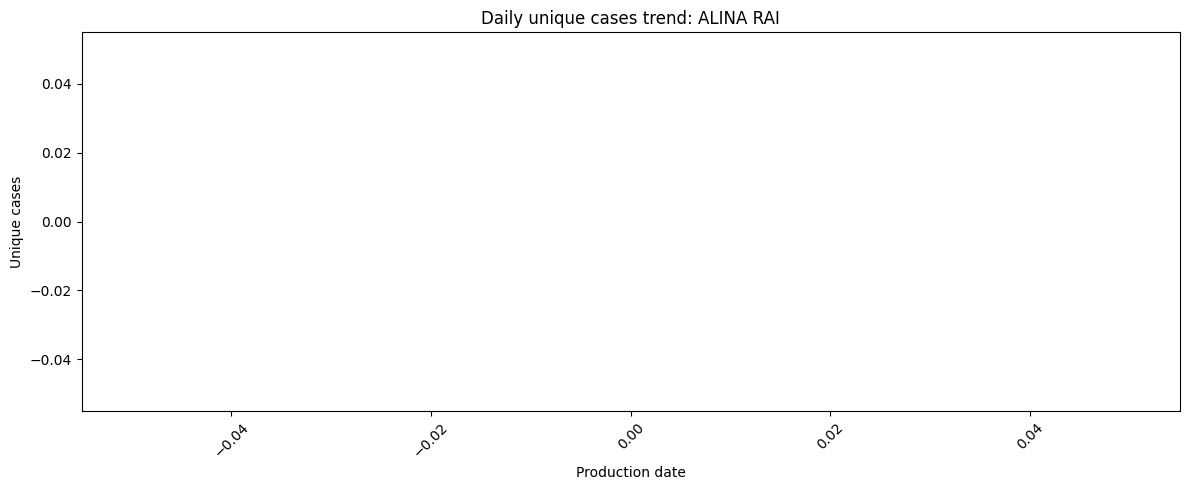

In [19]:
if EMPLOYEE_NAME:
    emp_daily = daily_combo[daily_combo['matched_employee_name'] == EMPLOYEE_NAME].copy()
    emp_hist = historical_combo[historical_combo['matched_employee_name'] == EMPLOYEE_NAME].copy()
    emp_best_combo = employee_best_day_combo[employee_best_day_combo['matched_employee_name'] == EMPLOYEE_NAME].copy()
    emp_recs = employee_recommendations[employee_recommendations['matched_employee_name'] == EMPLOYEE_NAME].copy()

    print('--- Historical top combos ---')
    display(emp_hist.sort_values(['avg_daily_unique_cases', 'historical_total_unique_cases'], ascending=False).head(5))

    print('--- Best day by combo ---')
    display(emp_best_combo.sort_values(['daily_unique_cases', 'daily_touches'], ascending=False).head(5))

    print('--- Recommendations ---')
    display(emp_recs.head(10))

    # Daily trend chart by total daily unique cases
    emp_daily_total = (
        emp_daily.groupby('production_date', as_index=False)
        .agg(total_daily_unique_cases=('daily_unique_cases', 'sum'))
        .sort_values('production_date')
    )

    plt.figure(figsize=(12, 5))
    plt.plot(emp_daily_total['production_date'], emp_daily_total['total_daily_unique_cases'])
    plt.title(f'Daily unique cases trend: {EMPLOYEE_NAME}')
    plt.xlabel('Production date')
    plt.ylabel('Unique cases')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Set EMPLOYEE_NAME to run the individual deep-dive section.')


## 13. Leaderboards

Useful for management review.


In [20]:
# Top combos by historical average daily cases
leaderboard_avg_daily = historical_combo.sort_values(
    ['avg_daily_unique_cases', 'max_daily_unique_cases', 'active_days'],
    ascending=[False, False, False]
).reset_index(drop=True)

# Top single best-day performances across all employees
leaderboard_best_days = daily_combo.sort_values(
    ['daily_unique_cases', 'daily_touches'],
    ascending=[False, False]
).reset_index(drop=True)

leaderboard_avg_daily.head(25), leaderboard_best_days.head(25)


(                  matched_employee_name               matched_email  matched_shore   testname                                          payorname  active_days  historical_total_touches  \
 0                    Sukhraj Singh Gill           sugill@natera.com            CGS  SIGNATERA                          HUMANA MEDICARE ADVANTAGE            1                       230   
 1                  Susheel Chirra Varma           svarma@natera.com            CGS    HORIZON                                   CIGNA HEALTHCARE            1                       134   
 2                         Surrey Reilly                         NaN  UNKNOWN_SHORE   PROSPERA                          HUMANA MEDICARE ADVANTAGE            2                       264   
 3                Yogita Sanjay Deshmukh        ydeshmukh@natera.com            CGS    HORIZON                                    SIMPLY Medicaid            1                        97   
 4                           Sunil Kumar          sukumar@na

## 14. Export outputs

This writes all important tables to CSV and one Excel workbook.


In [21]:
# OUTPUT_DIR = 'employee_case_analysis_outputs'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# export_frames = {
#     'daily_combo': daily_combo,
#     'historical_combo': historical_combo,
#     'employee_best_historical_volume': employee_best_historical_volume,
#     'employee_best_historical_efficiency': employee_best_historical_efficiency,
#     'employee_best_day_overall': employee_best_day_overall,
#     'employee_best_day_combo': employee_best_day_combo,
#     'daily_pattern_summary': daily_pattern_summary,
#     'employee_recommendations': employee_recommendations,
#     'top_employee_recommendations': top_employee_recommendations,
#     'leaderboard_avg_daily': leaderboard_avg_daily,
#     'leaderboard_best_days': leaderboard_best_days,
# }

# for name, frame in export_frames.items():
#     frame.to_csv(os.path.join(OUTPUT_DIR, f'{name}.csv'), index=False)

# excel_path = os.path.join(OUTPUT_DIR, 'employee_case_analysis.xlsx')
# with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
#     for name, frame in export_frames.items():
#         frame.to_excel(writer, sheet_name=name[:31], index=False)

# print(f'Outputs written to: {OUTPUT_DIR}')
# print(f'Excel workbook: {excel_path}')


In [3]:
import pandas as pd
import os

INPUT_DIR = 'employee_case_analysis_outputs'
output_path = os.path.join(INPUT_DIR, 'employee_case_analysis.xlsx')

csv_files = {
    # 'daily_combo': 'daily_combo.csv',
    'historical_combo': 'historical_combo.csv',
    'employee_best_historical_volume': 'employee_best_historical_volume.csv',
    'employee_best_historical_efficiency': 'employee_best_historical_efficiency.csv',
    'employee_best_day_overall': 'employee_best_day_overall.csv',
    'employee_best_day_combo': 'employee_best_day_combo.csv',
    'daily_pattern_summary': 'daily_pattern_summary.csv',
    'employee_recommendations': 'employee_recommendations.csv',
    'top_employee_recommendations': 'top_employee_recommendations.csv',
    'leaderboard_avg_daily': 'leaderboard_avg_daily.csv'
    # 'leaderboard_best_days': 'leaderboard_best_days.csv',
}

with pd.ExcelWriter(output_path, engine='xlsxwriter') as writer:
    for sheet_name, file_name in csv_files.items():
        file_path = os.path.join(INPUT_DIR, file_name)
        df = pd.read_csv(file_path)
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print(f"Excel file created at: {output_path}")

Excel file created at: employee_case_analysis_outputs\employee_case_analysis.xlsx


## 15. Next steps

Possible next extensions:

1. Add date windows like last 30 / 60 / 90 days
2. Add manager/team dimensions from the roster mapping view
3. Build a train/test recommendation model using recency-weighted daily output
4. Push outputs to Power BI or Snowflake tables
5. Add fairness controls so recommendations do not overfit to low-volume combinations


### ============================================================
## Recency-Weighted Recommendation Model
### ============================================================

In [24]:
OUTPUT_DIR = 'employee_case_analysis_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

export_frames = {
    'recency_recommendations': recency_recommendations,
    # 'historical_combo': historical_combo,
}

for name, frame in export_frames.items():
    frame.to_csv(os.path.join(OUTPUT_DIR, f'{name}.csv'), index=False)